In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("zomato_dataset.csv")

In [7]:
df

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...
123652,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Reshmi Kebab,NaN,0,525.0
123653,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Large Tikka,NaN,0,525.0
123654,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Chukandri Tikka,NaN,0,525.0
123655,Ariena Boutique Hotel,3.9,4.2,13,523,Pizza,Purena,Raipur,Murgh Golden Kebab,NaN,0,525.0


In [8]:
df.shape

(123657, 12)

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Dining Rating', 'Delivery Rating', 'Dining Votes', 'Delivery Votes',
       'Votes', 'Prices'],
      dtype='object')
Categorical Columns: Index(['Restaurant Name', 'Cuisine', 'Place Name', 'City', 'Item Name',
       'Best Seller'],
      dtype='object')


In [10]:
print(df.isnull().sum())

Restaurant Name        0
Dining Rating      32236
Delivery Rating     1280
Dining Votes           0
Delivery Votes         0
Cuisine                0
Place Name             0
City                   0
Item Name              0
Best Seller        95715
Votes                  0
Prices                 0
dtype: int64


In [11]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

/var/folders/7j/4mfq49jx199954g_vfv6fq_80000gn/T/ipykernel_12711/3132419990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [12]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/var/folders/7j/4mfq49jx199954g_vfv6fq_80000gn/T/ipykernel_12711/1925696021.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [13]:
print(df.isnull().sum())

Restaurant Name    0
Dining Rating      0
Delivery Rating    0
Dining Votes       0
Delivery Votes     0
Cuisine            0
Place Name         0
City               0
Item Name          0
Best Seller        0
Votes              0
Prices             0
dtype: int64


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
df

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,207,3.9,4.2,39,0,12,184,5,41530,0,84,249.0
1,207,3.9,4.2,39,0,12,184,5,12242,0,45,129.0
2,207,3.9,4.2,39,0,12,184,5,12837,0,39,189.0
3,207,3.9,4.2,39,0,12,184,5,9249,0,43,189.0
4,207,3.9,4.2,39,0,12,184,5,46959,6,31,205.0
...,...,...,...,...,...,...,...,...,...,...,...,...
123652,51,3.9,4.2,13,523,31,240,15,33734,0,0,525.0
123653,51,3.9,4.2,13,523,31,240,15,33691,0,0,525.0
123654,51,3.9,4.2,13,523,31,240,15,33643,0,0,525.0
123655,51,3.9,4.2,13,523,31,240,15,33654,0,0,525.0


In [16]:
df = pd.get_dummies(df, columns=cat_cols)

In [17]:
df

,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Votes,Prices,Restaurant Name_0,Restaurant Name_1,Restaurant Name_2,Restaurant Name_3,...,Best Seller_3,Best Seller_4,Best Seller_5,Best Seller_6,Best Seller_7,Best Seller_8,Best Seller_9,Best Seller_10,Best Seller_11,Best Seller_12
0,3.9,4.2,39,0,84,249.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,3.9,4.2,39,0,45,129.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3.9,4.2,39,0,39,189.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3.9,4.2,39,0,43,189.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,3.9,4.2,39,0,31,205.0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123652,3.9,4.2,13,523,0,525.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
123653,3.9,4.2,13,523,0,525.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
123654,3.9,4.2,13,523,0,525.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
123655,3.9,4.2,13,523,0,525.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


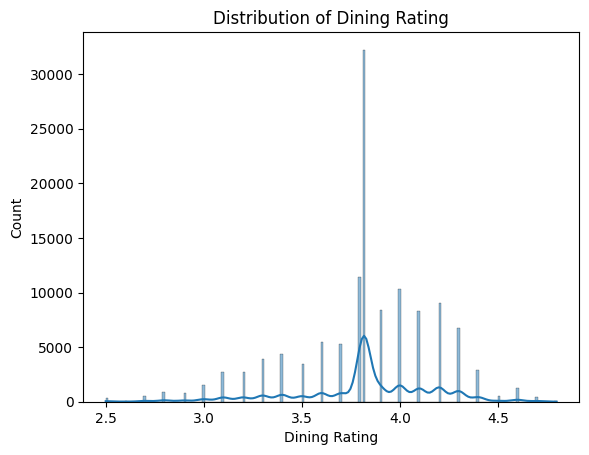

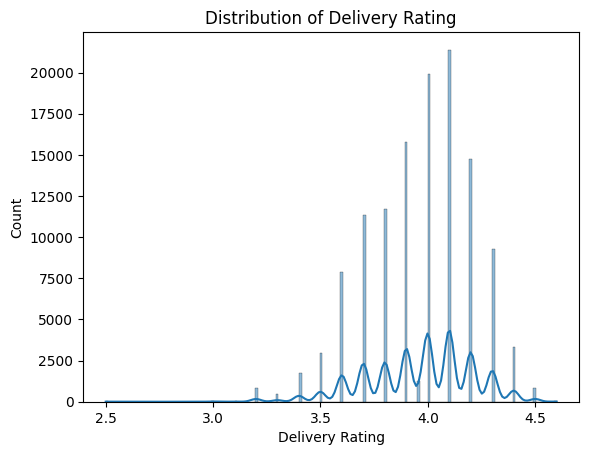

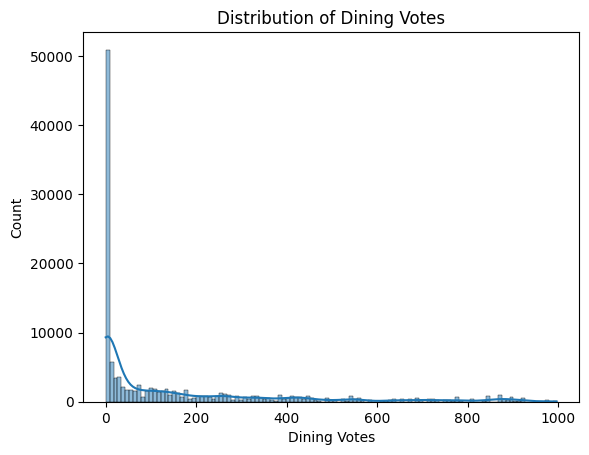

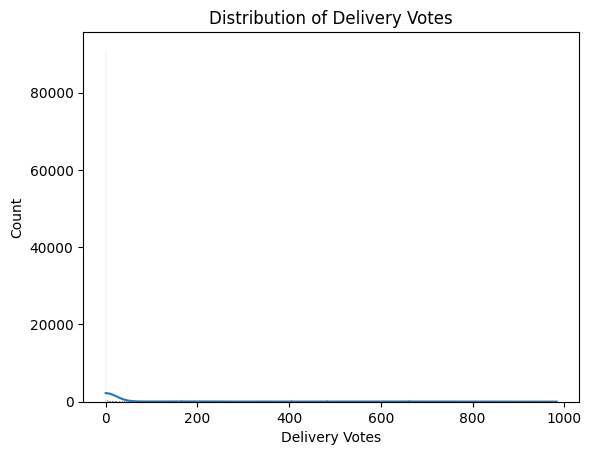

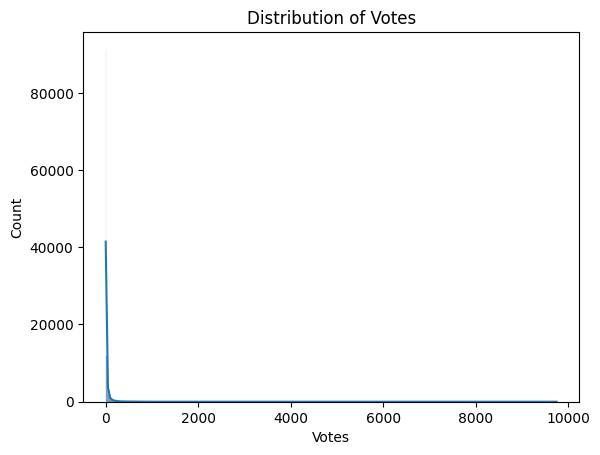

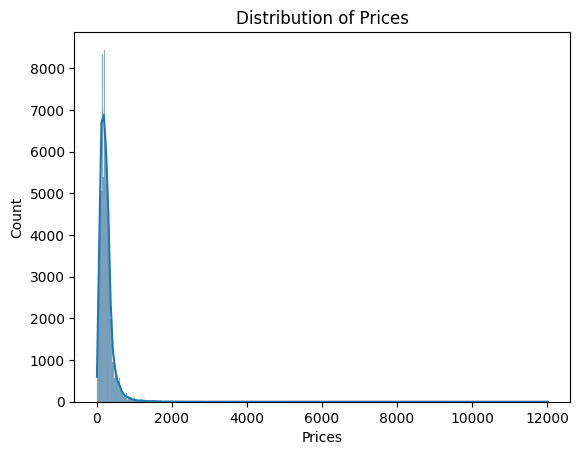

In [18]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

/var/folders/7j/4mfq49jx199954g_vfv6fq_80000gn/T/ipykernel_12711/2398586238.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


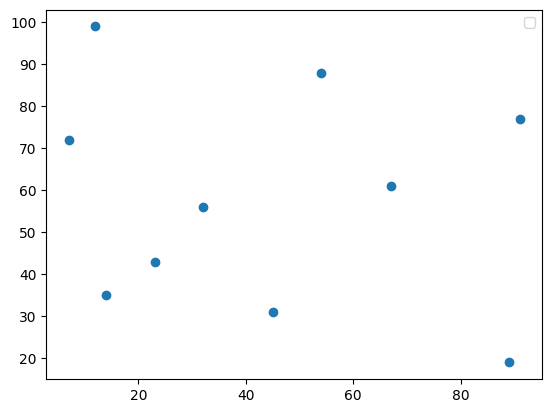

In [20]:
x = np.array([12, 45, 7, 32, 89, 54, 23, 67, 14, 91])
y = np.array([99, 31, 72, 56, 19, 88, 43, 61, 35, 77])
plt.scatter(x=x,y=y)
plt.legend()